# 1. Introduction

**This project focuses on improving fetal weight estimation during pregnancy by analyzing maternal, obstetric, ultrasound, delivery, and neonatal-related features. Current fetal weight estimations, such as sonographic estimated fetal weight and clinical estimated fetal weight, may contain errors due to biological variability, measurement limitations, and differences between patients. Therefore, our goal is to explore whether data-driven methods can help identify patterns that may improve the reliability of these estimations.**

# 2. Import libraries

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.stats import chi2_contingency

# 3. Upload data

In [2]:
# True  = load CSV from a local folder, for VMware / local Jupyter / VS Code
# False = upload CSV manually, for Google Colab

USE_LOCAL_FILE = False

In [3]:
if USE_LOCAL_FILE:

    # If this notebook is inside the notebooks/ folder:
    DATA_DIR = Path("../data")

    # If this notebook is in the main project folder, use this instead:
    # DATA_DIR = Path("data")

    csv_files = list(DATA_DIR.glob("*.csv"))

    if len(csv_files) == 0:
        raise FileNotFoundError(f"No CSV files found in: {DATA_DIR.resolve()}")

    file_path = csv_files[0]
    print("Loading local file:", file_path)

else:

    # Option 2: Google Colab upload

    from google.colab import files

    uploaded = files.upload()

    if len(uploaded) == 0:
        raise FileNotFoundError("No file was uploaded.")

    file_path = next(iter(uploaded))
    print("Loading uploaded file:", file_path)

# Read CSV
df = pd.read_csv(file_path, encoding="utf-8-sig")

# Keep raw backup before any cleaning
df_raw = df.copy()

Saving synthetic_pregnancy_dataset_15000.csv to synthetic_pregnancy_dataset_15000 (3).csv
Loading uploaded file: synthetic_pregnancy_dataset_15000 (3).csv


# 4. EDA

In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", 100)

records of data and number features in the data

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 15000
Number of columns: 37


Top 5 records of the data

In [6]:
df.head()

,תז,גיל האישה,עישון,אלכוהול,סמים,גיל הריון בלידה,AB,CS,EUP,G,P,LC,VBAC,GDM,DM,PPH,BLOOD TRANSFUSION,SHOULDER DYSTOCIA,גובה,משקל טרם ההריון,משקל סביב לידה,השראת לידה,אפידורל,הערכת משקל סונוגרפית,הערכת משקל קלינית,AFI,אופן הלידה,קרעים בתעלת לידה,תז ילוד,מין ילוד,אפגר1,אפגר 5,משקל יילוד בלידה,PH מחבל הטבור,אשפוז בNICU,STILLBIRTH,ממוצע משקלי לידות בעבר
0,200000000,34,0,0,0,39.2,0,0,0,2,1,1,0,0,0,0,0,0,163.0,45.2,59.7,0,1.0,3129.0,3649.0,7.5,רגילה,0,300000000,זכר,8,10,2985,7.19,0,0,3294.0
1,200000001,30,0,0,0,38.7,0,0,1,4,2,2,0,0,0,0,0,0,163.8,54.8,73.6,1,1.0,3195.0,3119.0,12.5,רגילה,0,300000001,נקבה,7,7,3133,7.42,0,0,3043.0
2,200000002,35,1,0,0,38.9,0,1,0,3,2,2,0,0,0,0,0,0,164.5,61.4,77.7,0,1.0,3058.0,NaN,13.9,מכשירנית,3,300000002,זכר,8,9,2852,7.20,0,0,3052.0
3,200000003,40,0,0,0,38.4,0,0,0,2,1,1,0,0,0,0,0,0,170.6,76.3,85.9,0,0.0,3078.0,3043.0,15.9,רגילה,3,300000003,נקבה,8,9,3362,7.29,0,0,3456.0
4,200000004,30,1,0,0,40.9,0,0,0,2,1,1,0,0,0,0,0,0,158.8,85.7,102.9,0,0.0,3343.0,3996.0,17.1,רגילה,0,300000004,זכר,9,10,3460,7.23,0,0,3078.0


Feature names

In [7]:
df.columns.tolist()

['תז',
 'גיל האישה',
 'עישון',
 'אלכוהול',
 'סמים',
 'גיל הריון בלידה',
 'AB',
 'CS',
 'EUP',
 'G',
 'P',
 'LC',
 'VBAC',
 'GDM',
 'DM',
 'PPH',
 'BLOOD TRANSFUSION',
 'SHOULDER DYSTOCIA',
 'גובה',
 'משקל טרם ההריון',
 'משקל סביב לידה',
 'השראת לידה',
 'אפידורל',
 'הערכת משקל סונוגרפית',
 'הערכת משקל קלינית',
 'AFI',
 'אופן הלידה',
 'קרעים בתעלת לידה',
 'תז ילוד',
 'מין ילוד',
 'אפגר1',
 'אפגר 5',
 'משקל יילוד בלידה',
 'PH מחבל הטבור',
 'אשפוז בNICU',
 'STILLBIRTH',
 'ממוצע משקלי לידות בעבר']

Type and count nulls of each feature

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   תז                      15000 non-null  int64  
 1   גיל האישה               15000 non-null  int64  
 2   עישון                   15000 non-null  int64  
 3   אלכוהול                 15000 non-null  int64  
 4   סמים                    15000 non-null  int64  
 5   גיל הריון בלידה         15000 non-null  float64
 6   AB                      15000 non-null  int64  
 7   CS                      15000 non-null  int64  
 8   EUP                     15000 non-null  int64  
 9   G                       15000 non-null  int64  
 10  P                       15000 non-null  int64  
 11  LC                      15000 non-null  int64  
 12  VBAC                    15000 non-null  int64  
 13  GDM                     15000 non-null  int64  
 14  DM                      15000 non-null

summary table - count nulls, missing ,unique values

In [9]:
summary_table = pd.DataFrame({
    "column_name": df.columns,
    "dtype": df.dtypes.values,
    "non_null_count": df.notnull().sum().values,
    "missing_count": df.isnull().sum().values,
    "missing_percent": (df.isnull().mean().values * 100).round(2),
    "unique_values": df.nunique().values
})

summary_table

,column_name,dtype,non_null_count,missing_count,missing_percent,unique_values
0,תז,int64,15000,0,0.00,15000
1,גיל האישה,int64,15000,0,0.00,31
2,עישון,int64,15000,0,0.00,2
3,אלכוהול,int64,15000,0,0.00,2
4,סמים,int64,15000,0,0.00,2
5,גיל הריון בלידה,float64,15000,0,0.00,142
6,AB,int64,15000,0,0.00,6
7,CS,int64,15000,0,0.00,4
8,EUP,int64,15000,0,0.00,3
9,G,int64,15000,0,0.00,9


Basic statistic view of all the different features

In [10]:
df.describe(include="all")

,תז,גיל האישה,עישון,אלכוהול,סמים,גיל הריון בלידה,AB,CS,EUP,G,P,LC,VBAC,GDM,DM,PPH,BLOOD TRANSFUSION,SHOULDER DYSTOCIA,גובה,משקל טרם ההריון,משקל סביב לידה,השראת לידה,אפידורל,הערכת משקל סונוגרפית,הערכת משקל קלינית,AFI,אופן הלידה,קרעים בתעלת לידה,תז ילוד,מין ילוד,אפגר1,אפגר 5,משקל יילוד בלידה,PH מחבל הטבור,אשפוז בNICU,STILLBIRTH,ממוצע משקלי לידות בעבר
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14850.000000,14700.000000,14325.000000,14775.000000,15000,15000.000000,1.500000e+04,15000,15000.000000,15000.000000,15000.000000,14100.000000,15000.000000,15000.000000,9475.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,רגילה,NaN,NaN,זכר,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11013,NaN,NaN,7696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.000075e+08,31.034533,0.126467,0.035733,0.016600,38.758853,0.307733,0.183333,0.050667,2.372667,0.992733,0.966933,0.032267,0.07760,0.018533,0.050533,0.018400,0.005267,163.986933,69.902453,81.868027,0.166467,0.424310,3196.857483,3202.610681,12.603411,NaN,0.567933,3.000075e+08,NaN,8.485667,9.222667,3203.524800,7.254832,0.065267,0.003533,3218.878734
std,4.330271e+03,5.650935,0.332386,0.185631,0.127771,1.808647,0.553402,0.430969,0.225321,1.175023,0.991739,0.977430,0.178216,0.26755,0.134874,0.219050,0.134397,0.072383,6.945211,14.196740,14.733850,0.372511,0.494254,522.051845,575.567883,4.056067,NaN,0.855083,4.330271e+03,NaN,1.098973,1.066003,463.626301,0.061622,0.247004,0.059339,334.593158
min,2.000000e+08,18.000000,0.000000,0.000000,0.000000,27.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,145.000000,42.000000,45.000000,0.000000,0.000000,598.000000,577.000000,1.000000,NaN,0.000000,3.000000e+08,NaN,0.000000,0.000000,709.000000,6.970000,0.000000,0.000000,2118.000000
25%,2.000037e+08,27.000000,0.000000,0.000000,0.000000,38.200000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,159.200000,59.675000,71.400000,0.000000,0.000000,2886.000000,2848.000000,9.900000,NaN,0.000000,3.000037e+08,NaN,8.000000,9.000000,2948.000000,7.210000,0.000000,0.000000,2994.000000
50%,2.000075e+08,31.000000,0.000000,0.000000,0.000000,39.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,164.000000,69.100000,81.100000,0.000000,0.000000,3221.000000,3230.000000,12.600000,NaN,0.000000,3.000075e+08,NaN,9.000000,10.000000,3237.000000,7.260000,0.000000,0.000000,3214.000000
75%,2.000112e+08,35.000000,0.000000,0.000000,0.000000,39.800000,1.000000,0.000000,0.000000,3.000000,2.000000,2.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,168.700000,79.100000,91.500000,0.000000,1.000000,3552.250000,3592.000000,15.300000,NaN,1.000000,3.000112e+08,NaN,9.000000,10.000000,3512.000000,7.300000,0.000000,0.000000,3443.000000


How many duplicate rows are there

In [11]:
duplicate_rows = df.duplicated().sum()

print("Number of duplicated rows:", duplicate_rows)

Number of duplicated rows: 0


Count duplicate ID's

In [12]:
print("Duplicated mother IDs:", df["תז"].duplicated().sum())
print("Duplicated newborn IDs:", df["תז ילוד"].duplicated().sum())

Duplicated mother IDs: 0
Duplicated newborn IDs: 0


Drop the ID's to avoid overfitting

In [13]:
# Remove identifier columns that should not be used in analysis/modeling
id_columns = ["תז", "תז ילוד"]

df = df.drop(columns=id_columns, errors="ignore")

print("ID columns removed.")
print("New shape:", df.shape)

ID columns removed.
New shape: (15000, 35)


Name of features after ID's removed

In [14]:
df.columns.tolist()

['גיל האישה',
 'עישון',
 'אלכוהול',
 'סמים',
 'גיל הריון בלידה',
 'AB',
 'CS',
 'EUP',
 'G',
 'P',
 'LC',
 'VBAC',
 'GDM',
 'DM',
 'PPH',
 'BLOOD TRANSFUSION',
 'SHOULDER DYSTOCIA',
 'גובה',
 'משקל טרם ההריון',
 'משקל סביב לידה',
 'השראת לידה',
 'אפידורל',
 'הערכת משקל סונוגרפית',
 'הערכת משקל קלינית',
 'AFI',
 'אופן הלידה',
 'קרעים בתעלת לידה',
 'מין ילוד',
 'אפגר1',
 'אפגר 5',
 'משקל יילוד בלידה',
 'PH מחבל הטבור',
 'אשפוז בNICU',
 'STILLBIRTH',
 'ממוצע משקלי לידות בעבר']

Define Expected Column Types

In [15]:
# Expected column groups based on the project data dictionary

binary_cols = [
    "עישון",
    "אלכוהול",
    "סמים",
    "GDM",
    "DM",
    "PPH",
    "BLOOD TRANSFUSION",
    "SHOULDER DYSTOCIA",
    "השראת לידה",
    "אפידורל",
    "אשפוז בNICU",
    "STILLBIRTH"
]

count_integer_cols = [
    "AB",
    "CS",
    "EUP",
    "G",
    "P",
    "LC",
    "VBAC"
]

numeric_cols = [
    "גיל האישה",
    "גיל הריון בלידה",
    "גובה",
    "משקל טרם ההריון",
    "משקל סביב לידה",
    "הערכת משקל סונוגרפית",
    "הערכת משקל קלינית",
    "AFI",
    "אפגר1",
    "אפגר 5",
    "משקל יילוד בלידה",
    "PH מחבל הטבור",
    "ממוצע משקלי לידות בעבר",
    "קרעים בתעלת לידה"
]

categorical_cols = [
    "אופן הלידה",
    "מין ילוד"
]

print("Expected type groups were defined.")

Expected type groups were defined.


Wrong Data Types Check

In [16]:
type_issues = []

# Check numeric columns
for col in numeric_cols + count_integer_cols + binary_cols:
    if col in df.columns:
        converted = pd.to_numeric(df[col], errors="coerce")

        non_numeric_count = df[col].notna().sum() - converted.notna().sum()

        type_issues.append({
            "Feature": col,
            "ExpectedType": "Numeric",
            "ActualType": str(df[col].dtype),
            "NonNumericValues": non_numeric_count,
            "HasTypeIssue": non_numeric_count > 0
        })

# Check categorical columns
for col in categorical_cols:
    if col in df.columns:
        is_object_or_category = (
            df[col].dtype == "object" or
            str(df[col].dtype) == "category"
        )

        type_issues.append({
            "Feature": col,
            "ExpectedType": "Categorical",
            "ActualType": str(df[col].dtype),
            "NonNumericValues": None,
            "HasTypeIssue": not is_object_or_category
        })

type_issues_df = pd.DataFrame(type_issues)

display(type_issues_df)

,Feature,ExpectedType,ActualType,NonNumericValues,HasTypeIssue
0,גיל האישה,Numeric,int64,0.0,False
1,גיל הריון בלידה,Numeric,float64,0.0,False
2,גובה,Numeric,float64,0.0,False
3,משקל טרם ההריון,Numeric,float64,0.0,False
4,משקל סביב לידה,Numeric,float64,0.0,False
5,הערכת משקל סונוגרפית,Numeric,float64,0.0,False
6,הערכת משקל קלינית,Numeric,float64,0.0,False
7,AFI,Numeric,float64,0.0,False
8,אפגר1,Numeric,int64,0.0,False
9,אפגר 5,Numeric,int64,0.0,False


Invalid Binary Values Check

In [17]:
binary_issues = []

for col in binary_cols:
    if col in df.columns:
        unique_values = sorted(df[col].dropna().unique())
        invalid_values = [val for val in unique_values if val not in [0, 1]]

        binary_issues.append({
            "Feature": col,
            "ExpectedValues": "0 / 1",
            "ActualUniqueValues": unique_values,
            "InvalidValues": invalid_values,
            "InvalidCount": df[col].isin(invalid_values).sum()
        })

binary_issues_df = pd.DataFrame(binary_issues)

display(binary_issues_df)

,Feature,ExpectedValues,ActualUniqueValues,InvalidValues,InvalidCount
0,עישון,0 / 1,"[0, 1]",[],0
1,אלכוהול,0 / 1,"[0, 1]",[],0
2,סמים,0 / 1,"[0, 1]",[],0
3,GDM,0 / 1,"[0, 1]",[],0
4,DM,0 / 1,"[0, 1]",[],0
5,PPH,0 / 1,"[0, 1]",[],0
6,BLOOD TRANSFUSION,0 / 1,"[0, 1]",[],0
7,SHOULDER DYSTOCIA,0 / 1,"[0, 1]",[],0
8,השראת לידה,0 / 1,"[0, 1]",[],0
9,אפידורל,0 / 1,"[0.0, 1.0]",[],0


# 5. Data Analysis

## 5.1 Distribution Analysis

In [35]:
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", 100)

if "df_clean_candidate" in globals():
    df_viz = df_clean_candidate.copy()
    print("Using df_clean_candidate for visualization.")
else:
    df_viz = df.copy()
    print("Using df for visualization.")


Using df for visualization.


Devide to numerical and categorical columns for visualization

In [36]:
df_plot = df_viz.copy()

numerical_cols = df_plot.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df_plot.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Move low-cardinality numeric columns into categorical
for col in numerical_cols.copy():
    if df_plot[col].nunique(dropna=True) <= 10:
        categorical_cols.append(col)
        numerical_cols.remove(col)

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['גיל האישה', 'גיל הריון בלידה', 'גובה', 'משקל טרם ההריון', 'משקל סביב לידה', 'הערכת משקל סונוגרפית', 'הערכת משקל קלינית', 'AFI', 'משקל יילוד בלידה', 'PH מחבל הטבור', 'ממוצע משקלי לידות בעבר']

Categorical columns:
['אופן הלידה', 'מין ילוד', 'עישון', 'אלכוהול', 'סמים', 'AB', 'CS', 'EUP', 'G', 'P', 'LC', 'VBAC', 'GDM', 'DM', 'PPH', 'BLOOD TRANSFUSION', 'SHOULDER DYSTOCIA', 'השראת לידה', 'אפידורל', 'קרעים בתעלת לידה', 'אפגר1', 'אפגר 5', 'אשפוז בNICU', 'STILLBIRTH']


Distribution of the numerical features

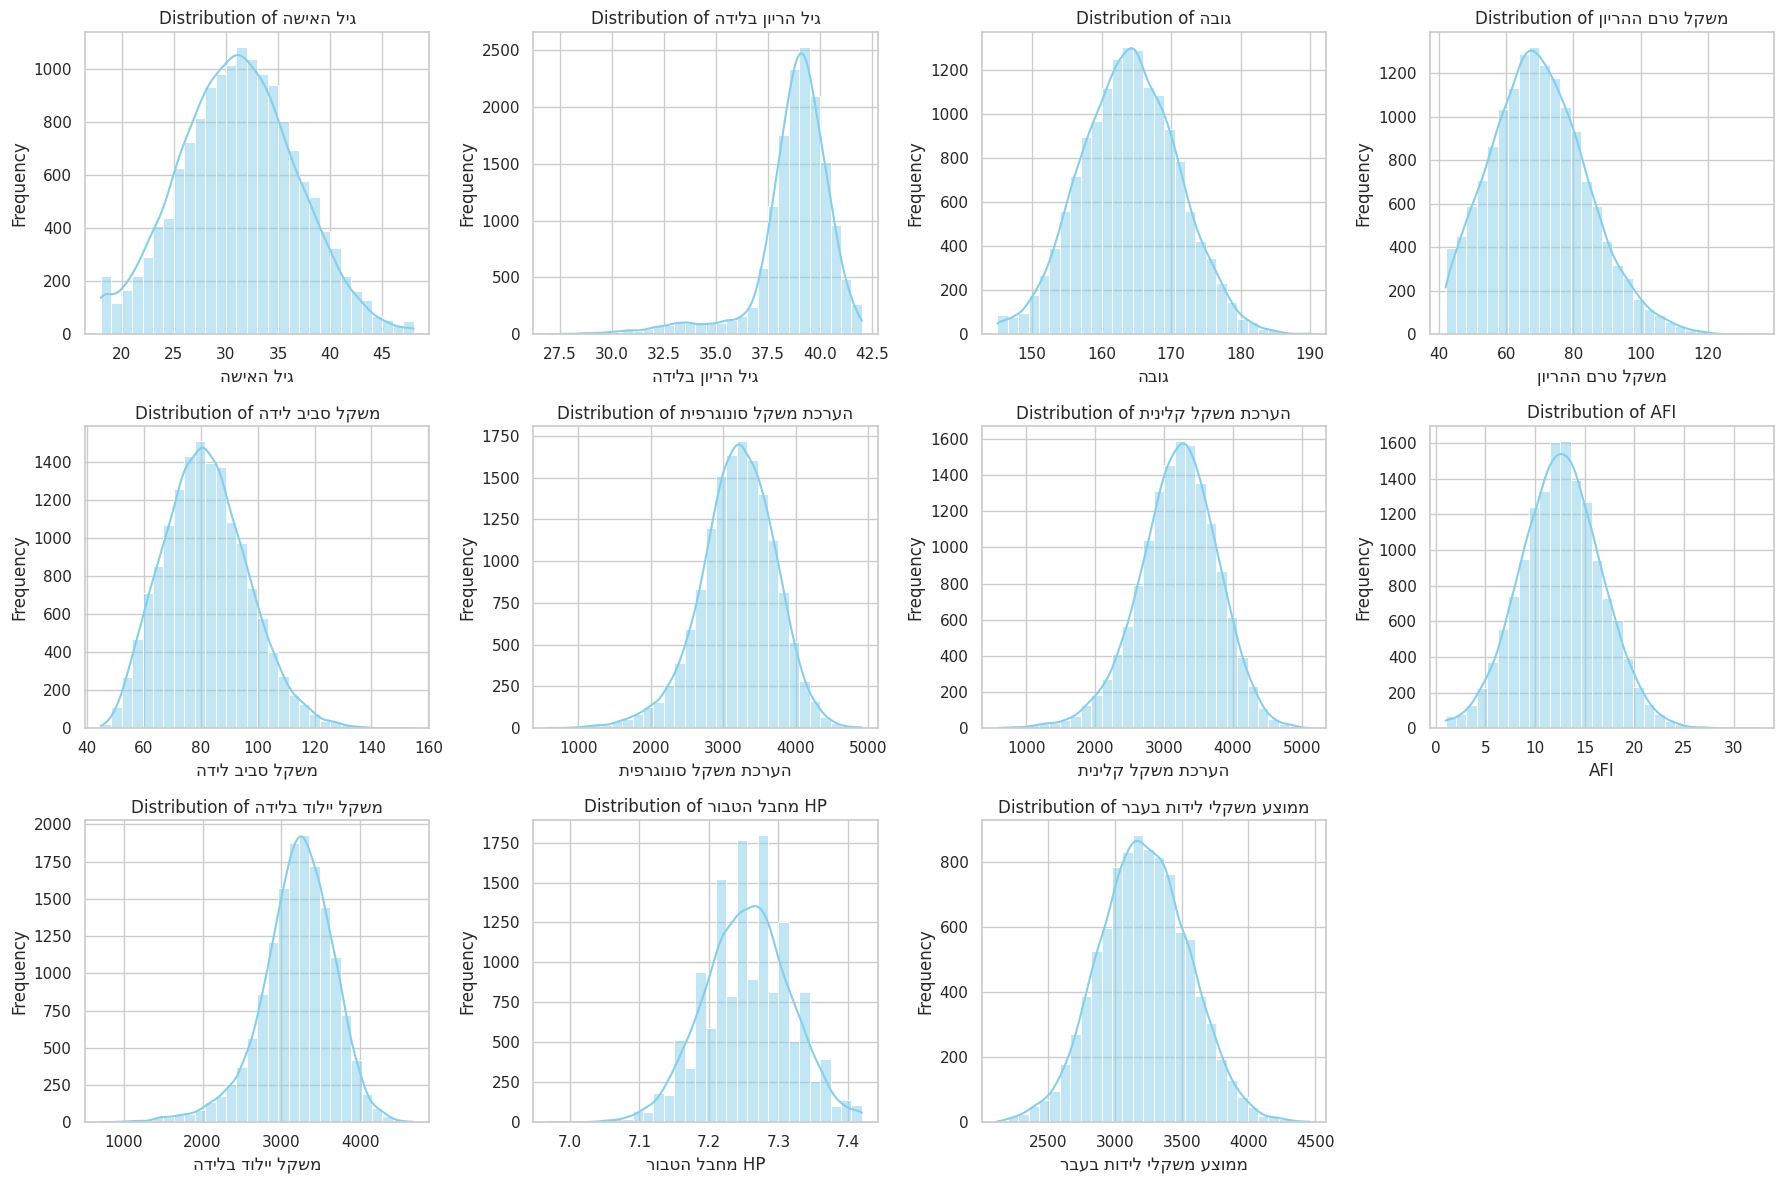

Numerical features displayed:
גיל האישה, גיל הריון בלידה, גובה, משקל טרם ההריון, משקל סביב לידה, הערכת משקל סונוגרפית, הערכת משקל קלינית, AFI, משקל יילוד בלידה, PH מחבל הטבור, ממוצע משקלי לידות בעבר


In [51]:
# Helper function for Hebrew display in matplotlib
def fix_hebrew_text(text):
    text = str(text)

    # If text contains Hebrew letters, reverse it for correct matplotlib display
    if re.search(r'[\u0590-\u05FF]', text):
        return text[::-1]

    return text


ncols = 4
nrows = (len(numerical_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df_plot, x=col, kde=True, bins=30, ax=axes[i], color="skyblue")

    fixed_col_name = fix_hebrew_text(col)

    axes[i].set_title(f"Distribution of {fixed_col_name}", fontsize=12)
    axes[i].set_xlabel(fixed_col_name)
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Features displayed in the histograms
print("Numerical features displayed:")
print(", ".join(numerical_cols))

Distribution of the categorial features in barplot

/tmp/ipykernel_15171/1394621133.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=temp_series_plot, ax=axes[i], palette="pastel")
/tmp/ipykernel_15171/1394621133.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=temp_series_plot, ax=axes[i], palette="pastel")
/tmp/ipykernel_15171/1394621133.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=temp_series_plot, ax=axes[i], palette="pastel")
/tmp/ipykernel_15171/1394621133.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v

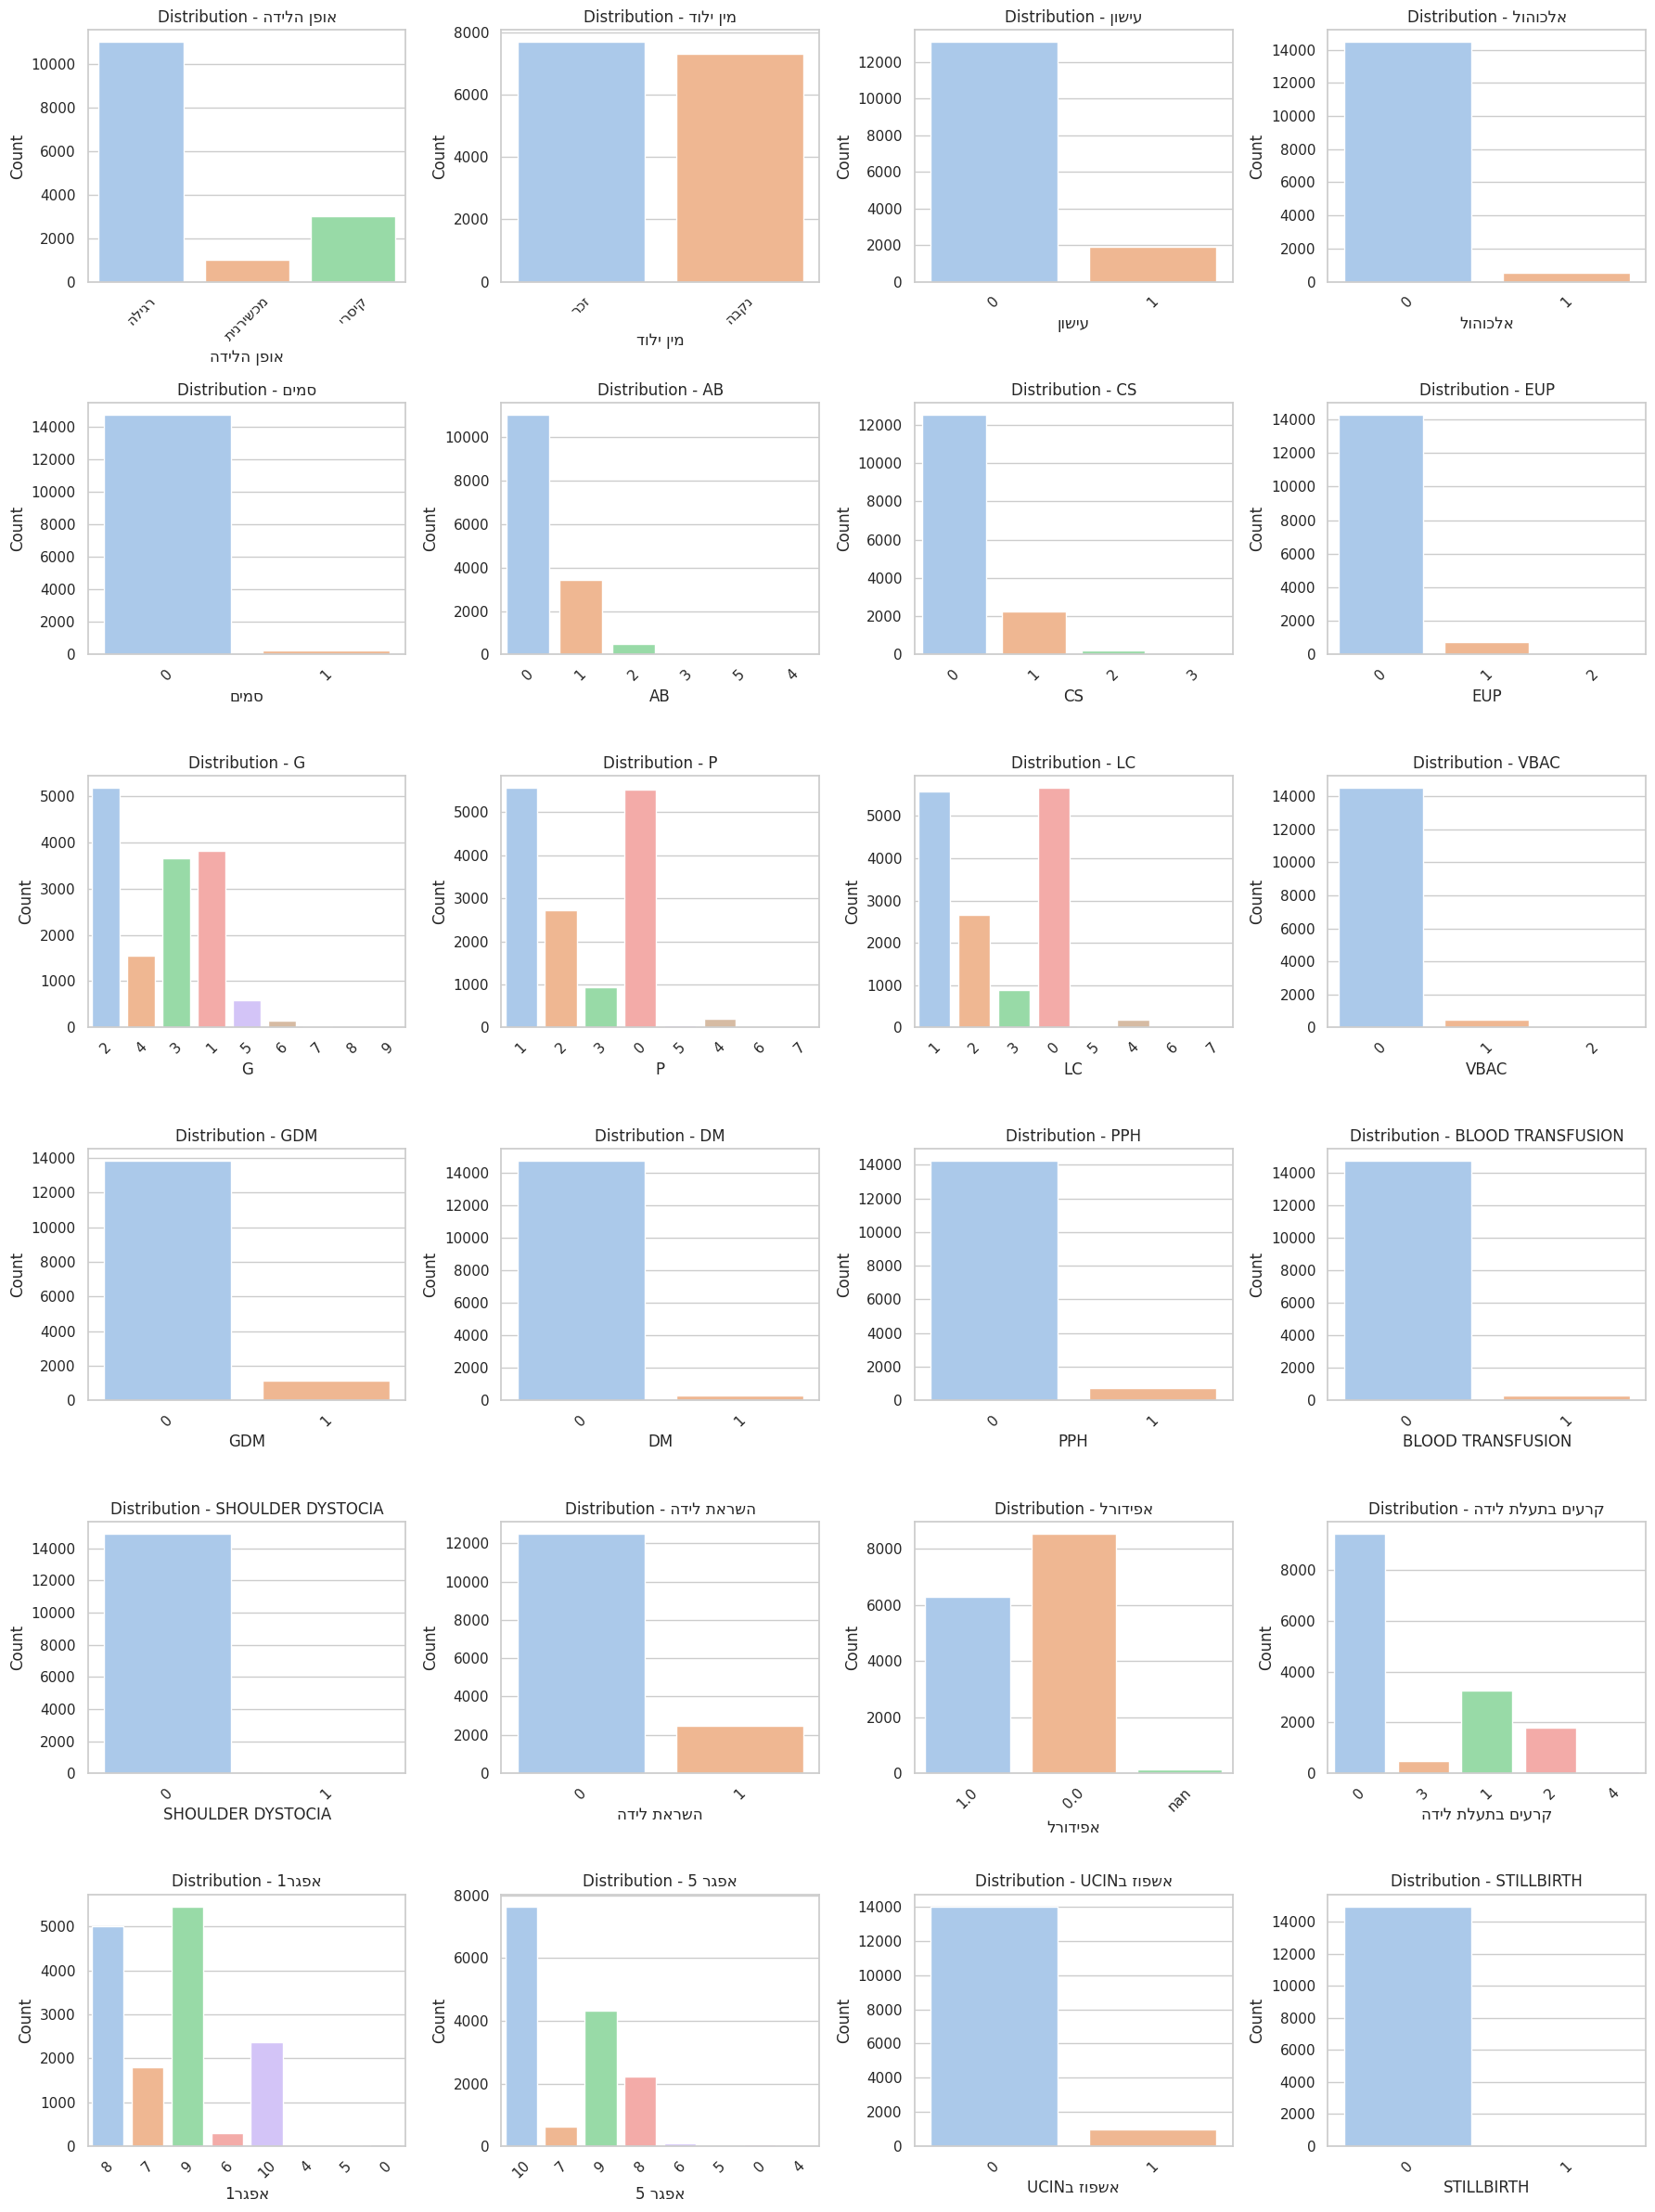

Categorical features displayed:
אופן הלידה, מין ילוד, עישון, אלכוהול, סמים, AB, CS, EUP, G, P, LC, VBAC, GDM, DM, PPH, BLOOD TRANSFUSION, SHOULDER DYSTOCIA, השראת לידה, אפידורל, קרעים בתעלת לידה, אפגר1, אפגר 5, אשפוז בNICU, STILLBIRTH


In [50]:
# Helper function for Hebrew display in matplotlib
def fix_hebrew_text(text):
    text = str(text)

    # If text contains Hebrew letters, reverse it for correct matplotlib display
    if re.search(r'[\u0590-\u05FF]', text):
        return text[::-1]

    return text


ncols = 4
nrows = (len(categorical_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    temp_series = df_plot[col].copy()

    # Keep only top 10 categories, group the rest as "Other"
    top_categories = temp_series.value_counts(dropna=False).nlargest(10).index
    temp_series = temp_series.apply(lambda x: x if x in top_categories else "Other")

    # Fix Hebrew category values for plotting
    temp_series_plot = temp_series.apply(fix_hebrew_text)

    sns.countplot(x=temp_series_plot, ax=axes[i], palette="pastel")

    # Fix Hebrew column name
    fixed_col_name = fix_hebrew_text(col)

    axes[i].set_title(f"Distribution - {fixed_col_name}", fontsize=12)
    axes[i].set_xlabel(fixed_col_name)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Features displayed in the plots
print("Categorical features displayed:")
print(", ".join(categorical_cols))

Distribution of the categorical features in a table

In [46]:
categorical_tables = {}

for col in categorical_cols:
    freq_table = df_plot[col].value_counts(dropna=False).reset_index()
    freq_table.columns = [col, "Count"]
    freq_table["Percentage"] = (freq_table["Count"] / len(df_plot) * 100).round(2)
    categorical_tables[col] = freq_table

for col, table in categorical_tables.items():
    print(f"\nDistribution table for: {col}")
    display(
        table.style
        .background_gradient(cmap="Greens", subset=["Count", "Percentage"])
        .set_properties(**{"text-align": "center" })
    )



Distribution table for: אופן הלידה


,אופן הלידה,Count,Percentage
0,רגילה,11013,73.420000
1,קיסרי,3000,20.000000
2,מכשירנית,987,6.580000



Distribution table for: מין ילוד


,מין ילוד,Count,Percentage
0,זכר,7696,51.310000
1,נקבה,7304,48.690000



Distribution table for: עישון


...

,אפגר 5,Count,Percentage
0,10,7652,51.010000
1,9,4323,28.820000
2,8,2232,14.880000
3,7,634,4.230000
4,6,90,0.600000
5,0,53,0.350000
6,5,15,0.100000
7,4,1,0.010000



Distribution table for: אשפוז בNICU


,אשפוז בNICU,Count,Percentage
0,0,14021,93.470000
1,1,979,6.530000



Distribution table for: STILLBIRTH


,STILLBIRTH,Count,Percentage
0,0,14947,99.650000
1,1,53,0.350000


## 5.2 Detecting anomalies & outliers

Invalid Ranges Check

In [18]:
range_rules = {
    "גיל האישה": (18, 50),
    "גיל הריון בלידה": (24, 42),
    "AB": (0, 20),
    "CS": (0, 10),
    "EUP": (0, 5),
    "G": (1, 20),
    "P": (0, 15),
    "LC": (0, 15),
    "VBAC": (0, 10),
    "גובה": (140, 200),
    "משקל טרם ההריון": (35, 180),
    "משקל סביב לידה": (40, 200),
    "הערכת משקל סונוגרפית": (400, 6000),
    "הערכת משקל קלינית": (400, 6000),
    "AFI": (0, 40),
    "אפגר1": (0, 10),
    "אפגר 5": (0, 10),
    "משקל יילוד בלידה": (400, 6000),
    "PH מחבל הטבור": (6.5, 7.5),
    "ממוצע משקלי לידות בעבר": (400, 6000),
    "קרעים בתעלת לידה": (0, 4)
}

range_issues = []

for col, (min_val, max_val) in range_rules.items():
    if col in df.columns:
        numeric_col = pd.to_numeric(df[col], errors="coerce")

        invalid_mask = (
            numeric_col.notna() &
            ((numeric_col < min_val) | (numeric_col > max_val))
        )

        range_issues.append({
            "Feature": col,
            "ValidRange": f"{min_val} - {max_val}",
            "InvalidCount": invalid_mask.sum(),
            "InvalidPercentage": round(invalid_mask.mean() * 100, 2),
            "MinValue": numeric_col.min(),
            "MaxValue": numeric_col.max()
        })

range_issues_df = pd.DataFrame(range_issues)

display(range_issues_df.sort_values("InvalidCount", ascending=False))

,Feature,ValidRange,InvalidCount,InvalidPercentage,MinValue,MaxValue
0,גיל האישה,18 - 50,0,0.0,18.00,48.00
1,גיל הריון בלידה,24 - 42,0,0.0,27.00,42.00
2,AB,0 - 20,0,0.0,0.00,5.00
3,CS,0 - 10,0,0.0,0.00,3.00
4,EUP,0 - 5,0,0.0,0.00,2.00
5,G,1 - 20,0,0.0,1.00,9.00
6,P,0 - 15,0,0.0,0.00,7.00
7,LC,0 - 15,0,0.0,0.00,7.00
8,VBAC,0 - 10,0,0.0,0.00,2.00
9,גובה,140 - 200,0,0.0,145.00,190.00


Invalid Categorical Values Check

In [19]:
valid_categories = {
    "אופן הלידה": ["רגילה", "מכשירנית", "קיסרי"],
    "מין ילוד": ["זכר", "נקבה"]
}

categorical_issues = []

for col, valid_values in valid_categories.items():
    if col in df.columns:
        actual_values = sorted(df[col].dropna().unique())
        invalid_values = [val for val in actual_values if val not in valid_values]

        categorical_issues.append({
            "Feature": col,
            "ExpectedValues": valid_values,
            "ActualValues": actual_values,
            "InvalidValues": invalid_values,
            "InvalidCount": df[col].isin(invalid_values).sum()
        })

categorical_issues_df = pd.DataFrame(categorical_issues)

display(categorical_issues_df)

,Feature,ExpectedValues,ActualValues,InvalidValues,InvalidCount
0,אופן הלידה,"[רגילה, מכשירנית, קיסרי]","[מכשירנית, קיסרי, רגילה]",[],0
1,מין ילוד,"[זכר, נקבה]","[זכר, נקבה]",[],0


## 5.3  Correlation tests

In [53]:
# Use clean candidate if exists
if "df_clean_candidate" in globals():
    df_corr = df_clean_candidate.copy()
    print("Using df_clean_candidate for correlation analysis.")
else:
    df_corr = df.copy()
    print("Using df for correlation analysis.")

# Helper function for Hebrew display in matplotlib
def fix_hebrew_text(text):
    text = str(text)
    if re.search(r'[\u0590-\u05FF]', text):
        return text[::-1]
    return text

Using df for correlation analysis.


Devide to binary , numerical and categorical columns in order to do correlation tests between them and for each one

In [54]:
# Remove technical quality flags if they exist
columns_to_exclude = [
    col for col in df_corr.columns
    if col.startswith("flag_") or col == "total_quality_flags"
]

df_corr = df_corr.drop(columns=columns_to_exclude, errors="ignore")

# Binary columns
binary_cols_corr = [
    "עישון",
    "אלכוהול",
    "סמים",
    "GDM",
    "DM",
    "PPH",
    "BLOOD TRANSFUSION",
    "SHOULDER DYSTOCIA",
    "השראת לידה",
    "אפידורל",
    "אשפוז בNICU",
    "STILLBIRTH"
]

binary_cols_corr = [col for col in binary_cols_corr if col in df_corr.columns]

# Categorical columns
categorical_cols_corr = [
    "אופן הלידה",
    "מין ילוד"
]

categorical_cols_corr = [col for col in categorical_cols_corr if col in df_corr.columns]

# Numeric columns
numeric_cols_corr = df_corr.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove binary columns from regular numeric correlation matrix
numeric_non_binary_cols = [
    col for col in numeric_cols_corr
    if col not in binary_cols_corr
]

print("Numeric non-binary columns:")
print(numeric_non_binary_cols)

print("\nBinary columns:")
print(binary_cols_corr)

print("\nCategorical columns:")
print(categorical_cols_corr)

Numeric non-binary columns:
['גיל האישה', 'גיל הריון בלידה', 'AB', 'CS', 'EUP', 'G', 'P', 'LC', 'VBAC', 'גובה', 'משקל טרם ההריון', 'משקל סביב לידה', 'הערכת משקל סונוגרפית', 'הערכת משקל קלינית', 'AFI', 'קרעים בתעלת לידה', 'אפגר1', 'אפגר 5', 'משקל יילוד בלידה', 'PH מחבל הטבור', 'ממוצע משקלי לידות בעבר']

Binary columns:
['עישון', 'אלכוהול', 'סמים', 'GDM', 'DM', 'PPH', 'BLOOD TRANSFUSION', 'SHOULDER DYSTOCIA', 'השראת לידה', 'אפידורל', 'אשפוז בNICU', 'STILLBIRTH']

Categorical columns:
['אופן הלידה', 'מין ילוד']


Spearman correlation measures how strongly two numeric variables move together by comparing their rank order rather than their exact values.

Spearman correlation was selected because the analysis at this stage is exploratory and no final target variable has been defined. It allows us to examine monotonic relationships between numeric features without assuming a strictly linear relationship, which is appropriate for clinical pregnancy-related data.

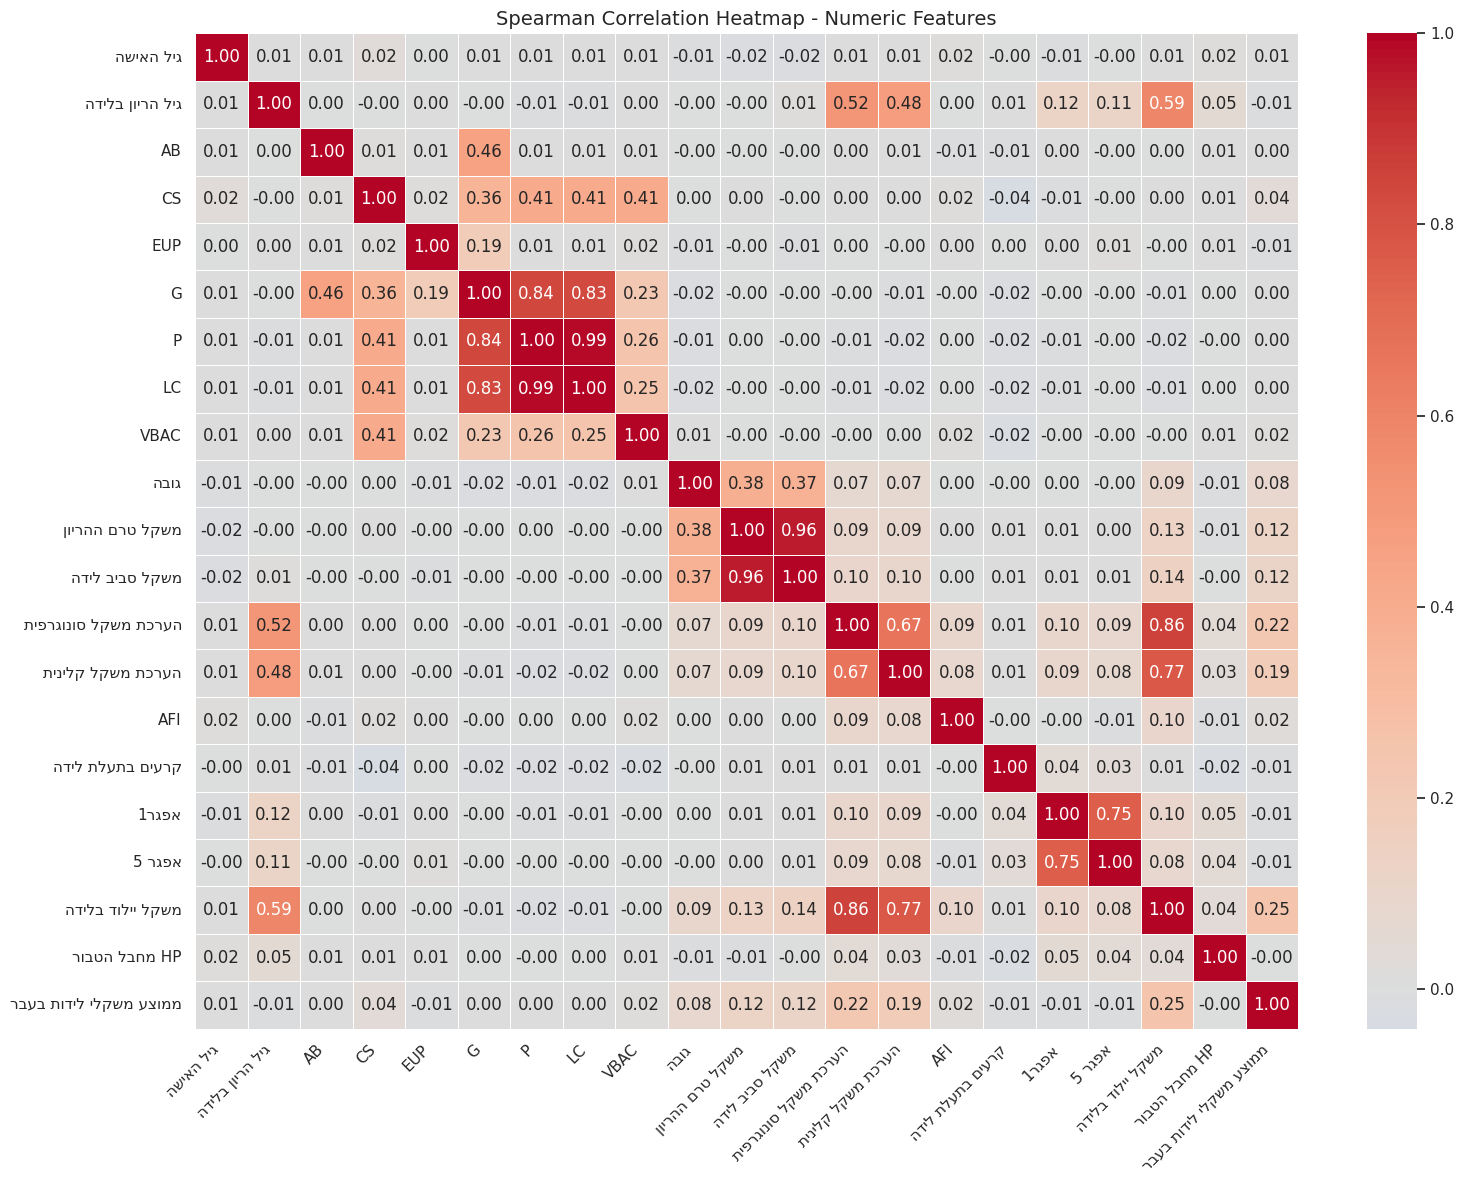

In [56]:
spearman_corr = df_corr[numeric_non_binary_cols].corr(method="spearman")

plt.figure(figsize=(16, 12))

fixed_labels = [fix_hebrew_text(col) for col in spearman_corr.columns]

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    xticklabels=fixed_labels,
    yticklabels=fixed_labels,
    linewidths=0.5
)

plt.title("Spearman Correlation Heatmap - Numeric Features", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Correlation between binary and numeric features

In [57]:
binary_numeric_summary = []

for binary_col in binary_cols_corr:
    for numeric_col in numeric_non_binary_cols:
        if binary_col in df_corr.columns and numeric_col in df_corr.columns:

            temp = df_corr[[binary_col, numeric_col]].dropna()

            if temp[binary_col].nunique() == 2:
                group_summary = temp.groupby(binary_col)[numeric_col].agg(["count", "mean", "median", "std"])

                if 0 in group_summary.index and 1 in group_summary.index:
                    mean_0 = group_summary.loc[0, "mean"]
                    mean_1 = group_summary.loc[1, "mean"]

                    binary_numeric_summary.append({
                        "BinaryFeature": binary_col,
                        "NumericFeature": numeric_col,
                        "Count_0": int(group_summary.loc[0, "count"]),
                        "Mean_0": round(mean_0, 2),
                        "Count_1": int(group_summary.loc[1, "count"]),
                        "Mean_1": round(mean_1, 2),
                        "MeanDifference_1_minus_0": round(mean_1 - mean_0, 2)
                    })

binary_numeric_summary_df = pd.DataFrame(binary_numeric_summary)

# Show strongest differences by absolute mean difference
binary_numeric_summary_df["AbsMeanDifference"] = binary_numeric_summary_df["MeanDifference_1_minus_0"].abs()

display(
    binary_numeric_summary_df
    .sort_values("AbsMeanDifference", ascending=False)
    .head(30)
)

,BinaryFeature,NumericFeature,Count_0,Mean_0,Count_1,Mean_1,MeanDifference_1_minus_0,AbsMeanDifference
222,אשפוז בNICU,הערכת משקל סונוגרפית,13739,3236.88,961,2624.69,-612.19,612.19
228,אשפוז בNICU,משקל יילוד בלידה,14021,3243.45,979,2631.67,-611.78,611.78
223,אשפוז בNICU,הערכת משקל קלינית,13386,3241.70,939,2645.42,-596.28,596.28
12,עישון,הערכת משקל סונוגרפית,12838,3222.56,1862,3019.62,-202.94,202.94
13,עישון,הערכת משקל קלינית,12506,3228.36,1819,3025.60,-202.76,202.76
60,סמים,משקל יילוד בלידה,14751,3206.89,249,3004.39,-202.50,202.50
55,סמים,הערכת משקל קלינית,14082,3205.96,243,3008.44,-197.53,197.53
54,סמים,הערכת משקל סונוגרפית,14456,3200.13,244,3002.71,-197.43,197.43
18,עישון,משקל יילוד בלידה,13103,3228.48,1897,3031.13,-197.35,197.35
76,GDM,הערכת משקל קלינית,13209,3188.55,1116,3369.08,180.53,180.53


Cramer's V is a measure of association between categorical variables

Cramer's V was used to measure the strength of association between categorical and binary variables. This is important because many clinical features in the dataset are not continuous numeric variables, and therefore require a categorical association measure rather than standard numeric correlation.

Here we show cramers v table

In [58]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)

    if confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
        return np.nan

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()

    r, k = confusion_matrix.shape

    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

cat_assoc_cols = binary_cols_corr + categorical_cols_corr + ["קרעים בתעלת לידה"]

cat_assoc_cols = [
    col for col in cat_assoc_cols
    if col in df_corr.columns
]

cramers_results = []

for i in range(len(cat_assoc_cols)):
    for j in range(i + 1, len(cat_assoc_cols)):
        col1 = cat_assoc_cols[i]
        col2 = cat_assoc_cols[j]

        temp = df_corr[[col1, col2]].dropna()

        if len(temp) > 0:
            v = cramers_v(temp[col1], temp[col2])

            cramers_results.append({
                "Feature 1": col1,
                "Feature 2": col2,
                "CramersV": round(v, 3) if pd.notna(v) else np.nan
            })

cramers_df = pd.DataFrame(cramers_results)

display(
    cramers_df
    .dropna()
    .sort_values("CramersV", ascending=False)
    .head(30)
)

,Feature 1,Feature 2,CramersV
103,אופן הלידה,קרעים בתעלת לידה,0.281
60,PPH,BLOOD TRANSFUSION,0.259
92,אפידורל,אופן הלידה,0.150
84,השראת לידה,אפידורל,0.147
66,PPH,אופן הלידה,0.083
1,עישון,סמים,0.079
74,BLOOD TRANSFUSION,אופן הלידה,0.075
83,SHOULDER DYSTOCIA,קרעים בתעלת לידה,0.066
42,GDM,SHOULDER DYSTOCIA,0.063
62,PPH,השראת לידה,0.063


Here we show cramers v heatmap

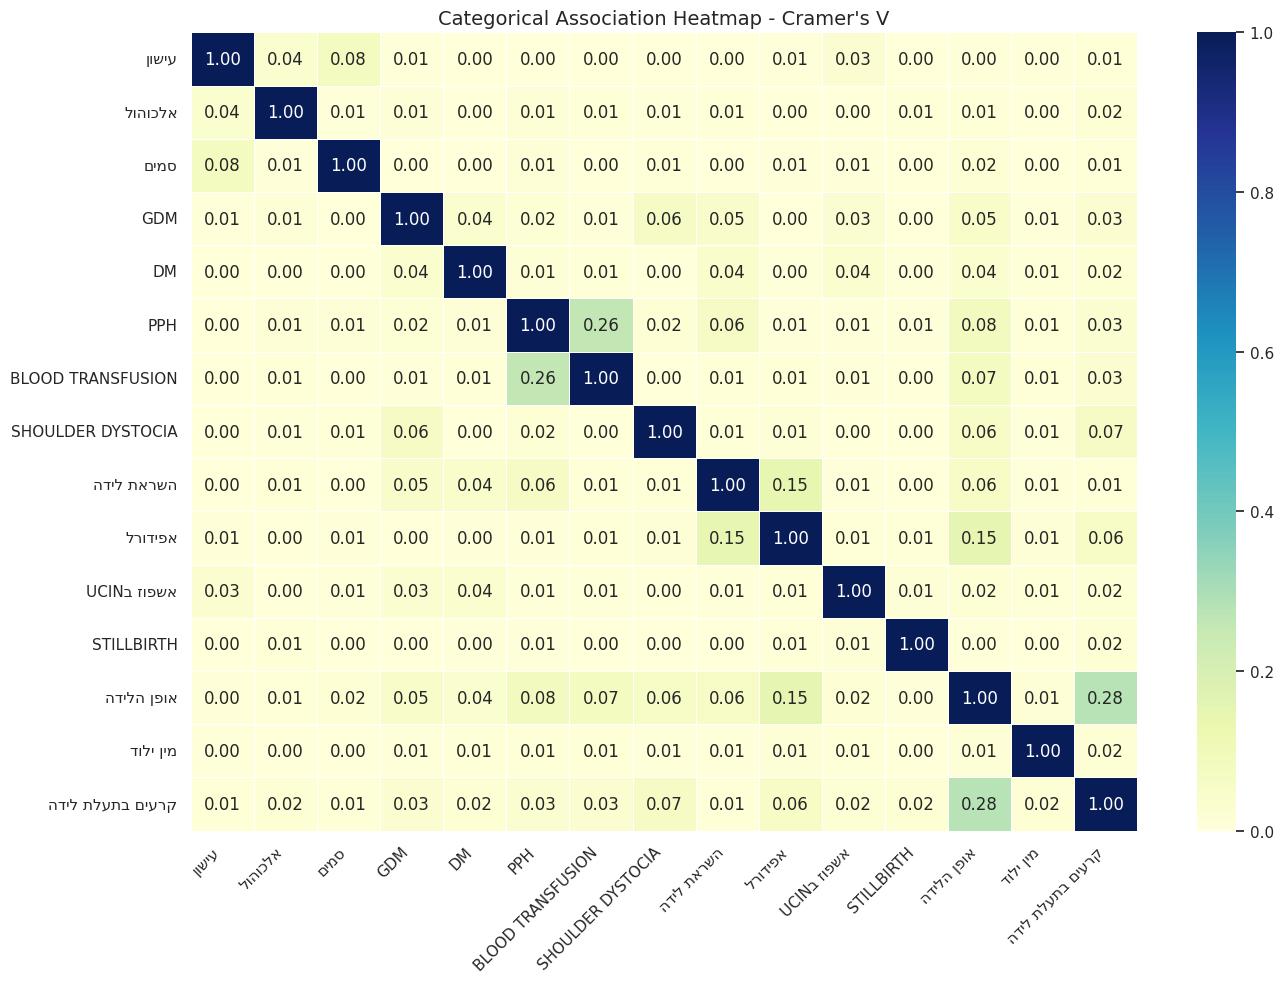

In [59]:
cramers_matrix = pd.DataFrame(
    np.eye(len(cat_assoc_cols)),
    index=cat_assoc_cols,
    columns=cat_assoc_cols
)

for _, row in cramers_df.dropna().iterrows():
    f1 = row["Feature 1"]
    f2 = row["Feature 2"]
    value = row["CramersV"]

    cramers_matrix.loc[f1, f2] = value
    cramers_matrix.loc[f2, f1] = value

plt.figure(figsize=(14, 10))

fixed_labels = [fix_hebrew_text(col) for col in cramers_matrix.columns]

sns.heatmap(
    cramers_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    xticklabels=fixed_labels,
    yticklabels=fixed_labels,
    linewidths=0.5
)

plt.title("Categorical Association Heatmap - Cramer's V", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()